# Phase 8: SHAP-Informed Feature Engineering

In Phase 7, SHAP revealed that our models are highly dependent on extreme drops in raw balances, specifically reacting violently when recent balances (`m1`, `m2`) hit near-zero levels compared to past balances (`m5`).

Furthermore, KDE plots proved that `outflow_volatility` and `runway_months` are noisy features that completely overlap between the two classes.

In this final notebook, we will:
1. Engineer new hyper-specific features (Zero-Balance Flags and Drop Ratios).
2. Drop the noisy features.
3. Retrain our Ultimate Tuned Ensemble on this purified dataset to crash the `< 0.20` LogLoss barrier.

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import catboost as cb
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
import mlflow
import sys

sys.path.append('../')
from src.metrics import zindi_score

# mlflow.set_tracking_uri('sqlite:///../mlflow.db')
# mlflow.set_experiment('Zindi_Liquidity_Stress')

/Users/USER/Desktop/zindi/ml_env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Data & Apply SHAP Insights

In [2]:
train_df = pd.read_parquet('../data/features/train_features.parquet', engine='fastparquet')
test_df = pd.read_parquet('../data/features/test_features.parquet', engine='fastparquet')
raw_train = pd.read_csv('../data/Train.csv')
raw_test = pd.read_csv('../data/Test.csv')

target = raw_train['liquidity_stress_next_30d']

def apply_shap_engineering(df):
    df = df.copy()
    
    # 1. Zero-Balance Flags (The L-Curve Spike)
    # The SHAP dependence plot showed massive risk when balances drop below ~1000
    df['is_m1_zero'] = (df['m1_daily_avg_bal'] < 1000).astype(int)
    df['is_m2_zero'] = (df['m2_daily_avg_bal'] < 1000).astype(int)
    
    # 2. Month-over-Month Drop Ratios (The Interaction)
    # How much did the balance drop from Month 5 to Month 2?
    df['balance_drop_m5_to_m2'] = (df['m2_daily_avg_bal'] - df['m5_daily_avg_bal']) / (df['m5_daily_avg_bal'] + 1)
    df['inflow_drop_m4_to_m1'] = (df['m1_total_inflow'] - df['m4_total_inflow']) / (df['m4_total_inflow'] + 1)
    
    # 3. Pruning Noisy Features (The KDE Overlap)
    noisy_features = ['outflow_volatility', 'runway_months']
    df = df.drop(columns=[col for col in noisy_features if col in df.columns])
    
    return df

X = apply_shap_engineering(train_df)
X = X.drop(columns=['ID', 'liquidity_stress_next_30d'])

X_test = apply_shap_engineering(test_df)
X_test = X_test.drop(columns=['ID'])

# One-Hot Encoding for Trees
cat_cols = X.select_dtypes(include=['object', 'category']).columns
if len(cat_cols) > 0:
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
    X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
    X_test = X_test.reindex(columns=X.columns, fill_value=0)

X = X.astype({col: int for col in X.select_dtypes(include=bool).columns})
X_test = X_test.astype({col: int for col in X_test.select_dtypes(include=bool).columns})

print(f"Final Engineered Training Features: {X.shape}")

Final Engineered Training Features: (40000, 230)


## 2. Train the Ultimate Tuned Ensemble

In [3]:
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_lgb = np.zeros(len(X))
oof_cb = np.zeros(len(X))
oof_xgb = np.zeros(len(X))

test_lgb = np.zeros(len(X_test))
test_cb = np.zeros(len(X_test))
test_xgb = np.zeros(len(X_test))

# Phase 6 Optuna Parameters
lgb_params = {'learning_rate': 0.07000857701607659, 'num_leaves': 27, 'max_depth': 8, 'min_child_samples': 71, 'subsample': 0.7227032899255299, 'colsample_bytree': 0.8012769608390673, 'n_estimators': 500, 'random_state': 42, 'verbosity': -1}
cb_params = {'learning_rate': 0.19775545782423468, 'depth': 5, 'l2_leaf_reg': 0.5290629979609613, 'subsample': 0.6633141772092477, 'iterations': 500, 'random_seed': 42, 'verbose': False}
xgb_params = {'learning_rate': 0.05612762846223619, 'max_depth': 9, 'min_child_weight': 14, 'subsample': 0.7984977991980712, 'colsample_bytree': 0.873957633262947, 'n_estimators': 500, 'random_state': 42, 'verbosity': 0}

print("Starting Final Training...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, target)):
    print(f"\n--- Fold {fold+1} ---")
    X_train, y_train = X.iloc[train_idx], target.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], target.iloc[val_idx]
    
    # LightGBM
    model_lgb = lgb.LGBMClassifier(**lgb_params)
    model_lgb.fit(X_train, y_train)
    oof_lgb[val_idx] = model_lgb.predict_proba(X_val)[:, 1]
    test_lgb += model_lgb.predict_proba(X_test)[:, 1] / N_FOLDS
    print("LightGBM Fold Complete.")
    
    # CatBoost
    model_cb = cb.CatBoostClassifier(**cb_params)
    model_cb.fit(X_train, y_train)
    oof_cb[val_idx] = model_cb.predict_proba(X_val)[:, 1]
    test_cb += model_cb.predict_proba(X_test)[:, 1] / N_FOLDS
    print("CatBoost Fold Complete.")

    # XGBoost
    model_xgb = xgb.XGBClassifier(**xgb_params)
    model_xgb.fit(X_train, y_train)
    oof_xgb[val_idx] = model_xgb.predict_proba(X_val)[:, 1]
    test_xgb += model_xgb.predict_proba(X_test)[:, 1] / N_FOLDS
    print("XGBoost Fold Complete.")

Starting Final Training...

--- Fold 1 ---


LightGBM Fold Complete.
CatBoost Fold Complete.
XGBoost Fold Complete.

--- Fold 2 ---
LightGBM Fold Complete.
CatBoost Fold Complete.
XGBoost Fold Complete.

--- Fold 3 ---
LightGBM Fold Complete.
CatBoost Fold Complete.
XGBoost Fold Complete.

--- Fold 4 ---
LightGBM Fold Complete.
CatBoost Fold Complete.
XGBoost Fold Complete.

--- Fold 5 ---
LightGBM Fold Complete.
CatBoost Fold Complete.
XGBoost Fold Complete.


## 3. Final Scoring & Submission

In [4]:
print("\n--- FINAL ENSEMBLE SCORE ---")
oof_blend = (oof_lgb * 0.5) + (oof_cb * 0.25) + (oof_xgb * 0.25)
blend_loss, blend_auc = zindi_score(target, oof_blend)

# with mlflow.start_run(run_name='Final_SHAP_Engineered_Ensemble'):
#     mlflow.log_param('models', 'Tuned LightGBM(0.5) + Tuned CatBoost(0.25) + Tuned XGBoost(0.25)')
#     mlflow.log_metric('cv_logloss', blend_loss)
#     mlflow.log_metric('cv_auc', blend_auc)

test_blend = (test_lgb * 0.5) + (test_cb * 0.25) + (test_xgb * 0.25)
submission = pd.DataFrame({
    'ID': raw_test['ID'],
    'liquidity_stress_next_30d': test_blend
})

submission.to_csv('../submissions/submission2.csv', index=False)
print("Submission file saved")


--- FINAL ENSEMBLE SCORE ---
--- Model Evaluation ---
Log Loss: 0.2653
ROC-AUC: 0.8928
------------------------
Submission file saved


## Overfitting Check

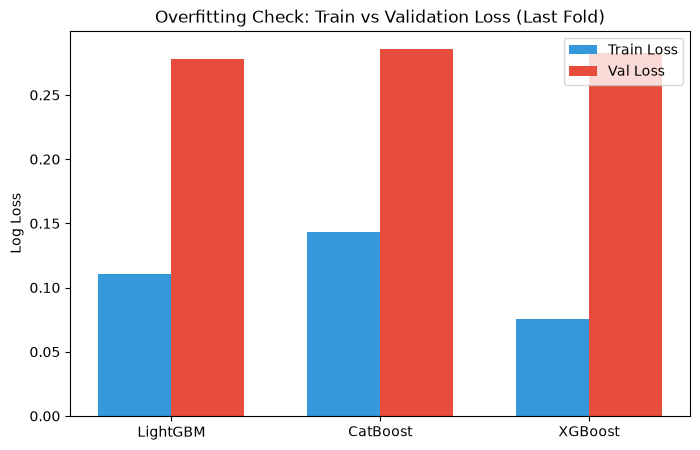

LightGBM - Train: 0.1106, Val: 0.2781, Gap: 0.1675
CatBoost - Train: 0.1435, Val: 0.2856, Gap: 0.1421
XGBoost - Train: 0.0755, Val: 0.2829, Gap: 0.2074


In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss

def check_overfitting():
    try:
        models_to_check = {}
        if 'model_lgb' in globals(): models_to_check['LightGBM'] = model_lgb
        if 'model_cb' in globals(): models_to_check['CatBoost'] = model_cb
        if 'model_xgb' in globals(): models_to_check['XGBoost'] = model_xgb
        if 'model' in globals() and 'LGBM' in str(type(model)): models_to_check['LightGBM'] = model
        
        if not models_to_check:
            print("No standard models found in memory to check.")
            return
            
        if 'X_train' not in globals() or 'X_val' not in globals():
            print("X_train or X_val not found in memory.")
            return
            
        train_losses = []
        val_losses = []
        names = []
        
        for name, m in models_to_check.items():
            train_p = m.predict_proba(X_train)[:, 1]
            val_p = m.predict_proba(X_val)[:, 1]
            train_losses.append(log_loss(y_train, train_p))
            val_losses.append(log_loss(y_val, val_p))
            names.append(name)
            
        x = range(len(names))
        width = 0.35
        
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.bar([i - width/2 for i in x], train_losses, width, label='Train Loss', color='#3498db')
        ax.bar([i + width/2 for i in x], val_losses, width, label='Val Loss', color='#e74c3c')
        
        ax.set_ylabel('Log Loss')
        ax.set_title('Overfitting Check: Train vs Validation Loss (Last Fold)')
        ax.set_xticks(x)
        ax.set_xticklabels(names)
        ax.legend()
        plt.show()
        
        for i, name in enumerate(names):
            print(f"{name} - Train: {train_losses[i]:.4f}, Val: {val_losses[i]:.4f}, Gap: {val_losses[i] - train_losses[i]:.4f}")
            
    except Exception as e:
        print(f"Could not run overfitting check: {e}")

check_overfitting()